<a href="https://colab.research.google.com/github/orelebile/chicago-crime-analysis/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Three questions to investigate
# 1. Which crimes are common (Knowing the most frequent crimes helps identify public safety priorities and trends)
# 2. How does crime vary by time (Helps understand when crimes are most likely to occur, useful for law enforcement scheduling and public awareness.)
# 3. Which community areas have the highest crime rates (Helps identify neighborhoods most affected and where interventions are needed)


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

crime_data=pd.read_csv('/content/Crimes_-_One_year_prior_to_present.csv')

#crime_data.info()

crime_data.head(5)


,CASE#,DATE OF OCCURRENCE,BLOCK,IUCR,PRIMARY DESCRIPTION,SECONDARY DESCRIPTION,LOCATION DESCRIPTION,ARREST,DOMESTIC,BEAT,WARD,FBI CD,X COORDINATE,Y COORDINATE,LATITUDE,LONGITUDE,LOCATION
0,JJ205388,04/03/2025 10:50:00 PM,049XX W SCHUBERT AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,N,Y,2521.0,31.0,14,1143030.0,1917505.0,41.929679,-87.749824,"(41.929678531, -87.749824286)"
1,JJ160428,02/24/2025 10:40:00 AM,059XX N GLENWOOD AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,SCHOOL - PUBLIC BUILDING,N,Y,2013.0,48.0,08B,1165910.0,1939379.0,41.989244,-87.665120,"(41.989243623, -87.665119726)"
2,JJ149631,02/14/2025 02:45:00 PM,054XX S WENTWORTH AVE,0860,THEFT,RETAIL THEFT,DEPARTMENT STORE,N,N,225.0,20.0,06,1175887.0,1869033.0,41.795991,-87.630542,"(41.795991039, -87.630542489)"
3,JJ212183,04/07/2025 05:00:00 PM,075XX S STONY ISLAND AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,N,Y,411.0,8.0,08B,1188234.0,1855158.0,41.757631,-87.585708,"(41.757630995, -87.585708249)"
4,JJ189129,03/19/2025 01:00:00 PM,021XX N MOZART ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,N,N,1414.0,1.0,14,1156975.0,1914091.0,41.920038,-87.698673,"(41.920038401, -87.698672834)"


In [ ]:
crime_data.shape
# the data frame contains 171666 rows and 17 columns

(171666, 17)

In [ ]:
crime_data.info()
#undersatnding the varriables in a data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CASE#                   171666 non-null  object 
 1   DATE  OF OCCURRENCE     171662 non-null  object 
 2   BLOCK                   171662 non-null  object 
 3    IUCR                   171662 non-null  object 
 4    PRIMARY DESCRIPTION    171662 non-null  object 
 5    SECONDARY DESCRIPTION  171662 non-null  object 
 6    LOCATION DESCRIPTION   170847 non-null  object 
 7   ARREST                  171661 non-null  object 
 8   DOMESTIC                171661 non-null  object 
 9   BEAT                    171661 non-null  float64
 10  WARD                    171661 non-null  float64
 11  FBI CD                  171661 non-null  object 
 12  X COORDINATE            171572 non-null  float64
 13  Y COORDINATE            171572 non-null  float64
 14  LATITUDE            

In [9]:
crime_data.describe()

,BEAT,WARD,X COORDINATE,Y COORDINATE,LATITUDE,LONGITUDE
count,171661.000000,171661.000000,1.715720e+05,1.715720e+05,171572.000000,171572.000000
mean,1141.881039,22.983683,1.165763e+06,1.887088e+06,41.845742,-87.667196
std,705.910030,13.932986,1.624608e+04,3.135949e+04,0.086237,0.059155
min,111.000000,1.000000,1.094182e+06,1.813909e+06,41.644608,-87.928903
25%,531.000000,10.000000,1.154465e+06,1.860163e+06,41.771722,-87.708254
50%,1031.000000,23.000000,1.167716e+06,1.893394e+06,41.863072,-87.659929
75%,1731.000000,34.000000,1.176943e+06,1.909696e+06,41.908132,-87.626218
max,2535.000000,50.000000,1.205117e+06,1.951517e+06,42.022559,-87.524532


In [ ]:
crime_data.isnull().sum()
#identifying data issues such as a empty entries or NaN entries


,0
CASE#,0
DATE OF OCCURRENCE,4
BLOCK,4
IUCR,4
PRIMARY DESCRIPTION,4
SECONDARY DESCRIPTION,4
LOCATION DESCRIPTION,819
ARREST,5
DOMESTIC,5
BEAT,5


In [ ]:
# Clean column names by stripping leading/trailing whitespace and replacing multiple spaces with single spaces
crime_data.columns = crime_data.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

crime_data = crime_data.dropna(subset=[
"DATE OF OCCURRENCE",
"BLOCK",
"IUCR",
"PRIMARY DESCRIPTION",
"SECONDARY DESCRIPTION",
"ARREST",
"DOMESTIC",
"BEAT",
"WARD",
"FBI CD"
])

In [ ]:
crime_data["LOCATION DESCRIPTION"] = crime_data["LOCATION DESCRIPTION"].fillna("Unknown")
#instead of dropping 819 location values, i have filled them with Unknown

/tmp/ipykernel_230/601713753.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crime_data["LOCATION DESCRIPTION"] = crime_data["LOCATION DESCRIPTION"].fillna("Unknown")


In [ ]:
crime_data = crime_data.dropna(subset=[
"X COORDINATE",
"Y COORDINATE",
"LATITUDE",
"LONGITUDE",
"LOCATION"
])
#dropping rows of missing location data.

In [ ]:
crime_data.isnull().sum()
#cross checking if there are any missing data

,0
CASE#,0
DATE OF OCCURRENCE,0
BLOCK,0
IUCR,0
PRIMARY DESCRIPTION,0
SECONDARY DESCRIPTION,0
LOCATION DESCRIPTION,0
ARREST,0
DOMESTIC,0
BEAT,0


In [ ]:
crime_data.duplicated().sum()
# np.int64(3) means there are 3 duplicated rows in the crime_data.

np.int64(3)

In [ ]:
crime_data= crime_data.drop_duplicates()
#dropping duplicates

In [ ]:
crime_data.duplicated().sum()
#checking if there are duplicates again (no duplicates)

np.int64(0)

In [ ]:
# Clean column names: strip whitespace and replace multiple spaces with single space
crime_data.columns = crime_data.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

# Now, convert 'DATE OF OCCURRENCE' column (after cleaning)
crime_data['DATE OF OCCURRENCE'] = pd.to_datetime(
    crime_data['DATE OF OCCURRENCE'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

crime_data.dtypes
#confirming if date formating worked and it worked :)

,0
CASE#,object
DATE OF OCCURRENCE,datetime64[ns]
BLOCK,object
IUCR,object
PRIMARY DESCRIPTION,object
SECONDARY DESCRIPTION,object
LOCATION DESCRIPTION,object
ARREST,object
DOMESTIC,object
BEAT,float64


In [ ]:
crime_data['DATE OF OCCURRENCE'].tail(10)
# it worked :)

,DATE OF OCCURRENCE
171656,2025-07-06 10:00:00
171657,2025-08-09 01:00:00
171658,2025-07-30 03:35:00
171659,2025-08-23 21:30:00
171660,2025-09-10 10:30:00
171661,2025-06-30 20:22:00
171662,NaT
171663,NaT
171664,NaT
171665,NaT


QUESTION 1: ADDRESSING CRIMES MOST COMMON IN CHICAGO

Insight:

- This bar chart establishes the shape of the dataset, showing that property crimes like Theft and Criminal Damage are significantly more frequent than violent crimes.

- It highlights that the city's primary law enforcement challenge, in terms of sheer volume, is managing larceny and property-related offenses rather than narcotics or more severe felonies.

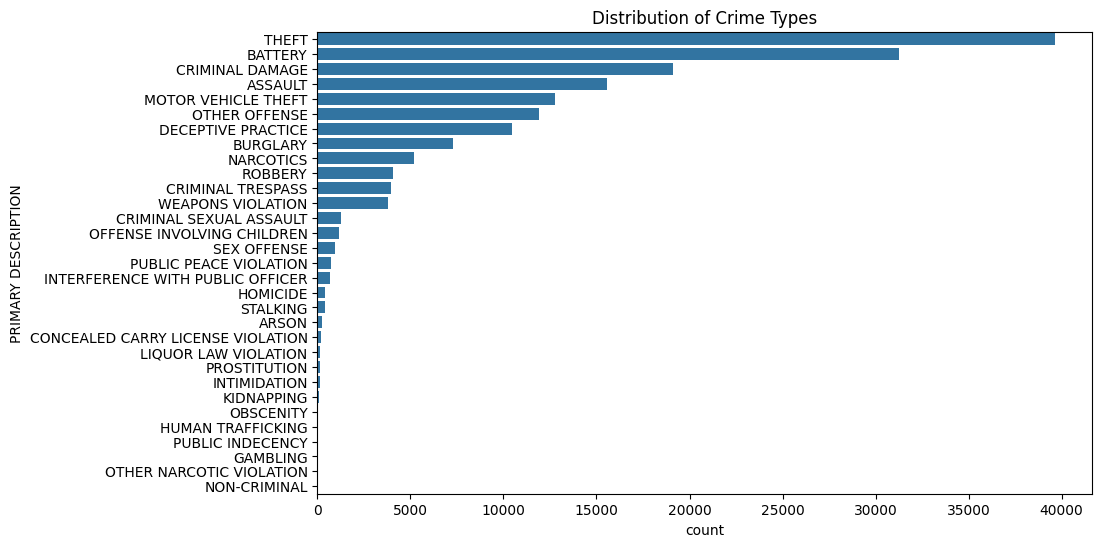

In [11]:
plt.figure(figsize=(10,6))
# Ensure column names are clean just before use to prevent KeyErrors
crime_data.columns = crime_data.columns.str.strip().str.replace(r'\s+', ' ', regex=True)
sns.countplot(y='PRIMARY DESCRIPTION',
              data=crime_data,
              order=crime_data['PRIMARY DESCRIPTION'].value_counts().index)
plt.title("Distribution of Crime Types")
plt.show()

QUESTION 2: TOP 10 CRIMES IN CHICAGO



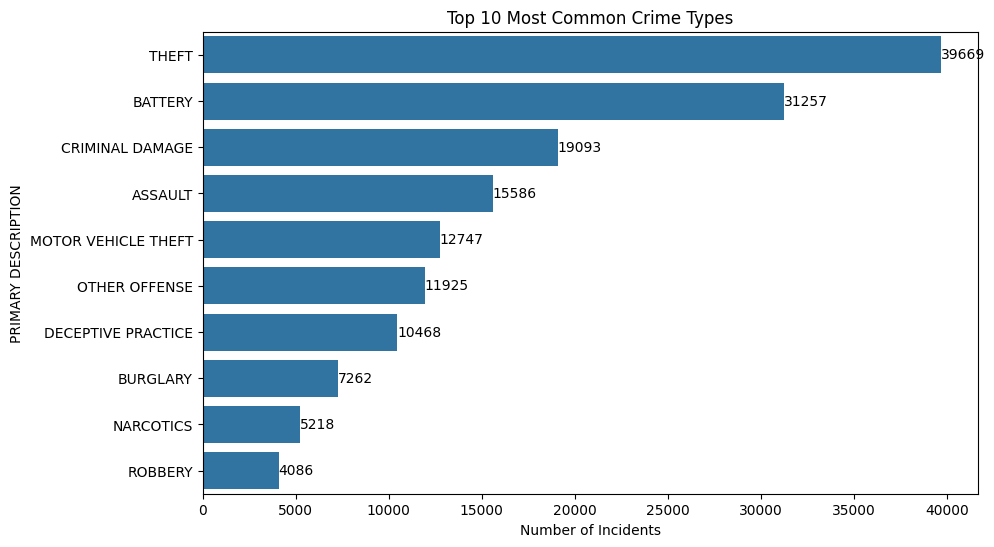

In [ ]:
#REFINING THE VISUALIZATION TO TOP TEN CRIMES
top10 = crime_data['PRIMARY DESCRIPTION'].value_counts().head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Most Common Crime Types")
plt.xlabel("Number of Incidents")
for i, value in enumerate(top10.values):
    ax.text(value, i, str(value), va='center')

plt.show()

#The most common crime in chicago is Theft, followed by battery, then criminal damage, assault, motor vehicle theft and so on...

QUESTION 3: Crime Variation by Time of Day (Hourly)

Insight:

- The data reveals a clear "night-owl" pattern where crime volume is at its lowest in the early morning (4 AM – 6 AM) and peaks steadily toward the late evening.

- The sharp increase starting at noon suggests that midday activity and the "after-work" hours are the highest-risk windows for criminal activity, likely due to increased foot traffic and opportunity.

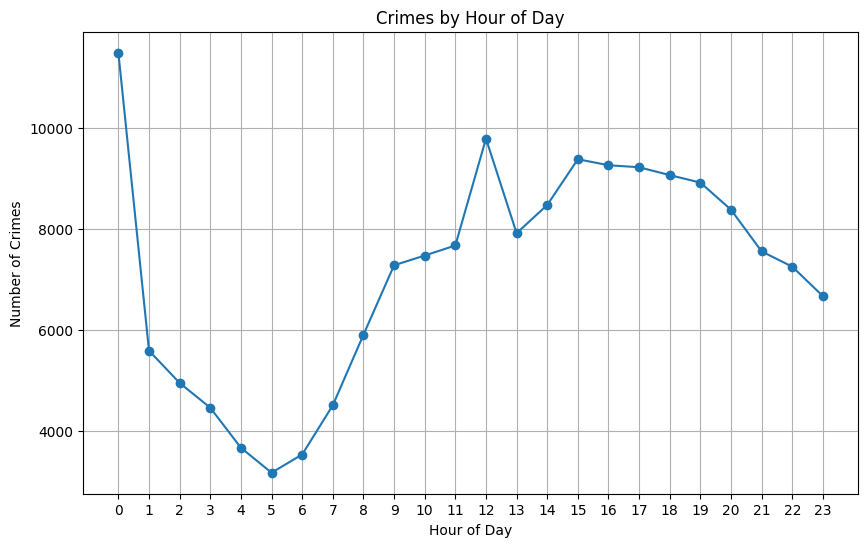

In [15]:
#ADDRESSING HOW CRIME VARY BY TIME
# Ensure 'DATE OF OCCURRENCE' is datetime type first, then drop NaT
# It seems the DATE OF OCCURRENCE column is still an object type in crime_data.
# Re-convert to datetime and handle NaT.
crime_data_temp = crime_data.copy() # Work on a copy to avoid SettingWithCopyWarning on original crime_data if it's a view
crime_data_temp['DATE OF OCCURRENCE'] = pd.to_datetime(
    crime_data_temp['DATE OF OCCURRENCE'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

# Now drop rows where 'DATE OF OCCURRENCE' is NaT
crime_data_cleaned = crime_data_temp.dropna(subset=['DATE OF OCCURRENCE']).copy()
crime_data_cleaned['Hour'] = crime_data_cleaned['DATE OF OCCURRENCE'].dt.hour

# Count crimes per hour
hourly_counts = crime_data_cleaned.groupby('Hour').size()

plt.figure(figsize=(10,6))
plt.plot(hourly_counts.index, hourly_counts.values, marker='o')

plt.title("Crimes by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.xticks(range(0,24))
plt.grid(True)

plt.show()

QUESTION 4: Crime Variation by Day of the Week

Insight:
- Surprisingly, the distribution across the week is relatively stable, but there is a noticeable uptick on Fridays and Saturdays.

-This suggests that weekend social activity correlates with a rise in incidents, while mid-week days (Tuesday/Wednesday) represent the "troughs" of criminal activity in the city.

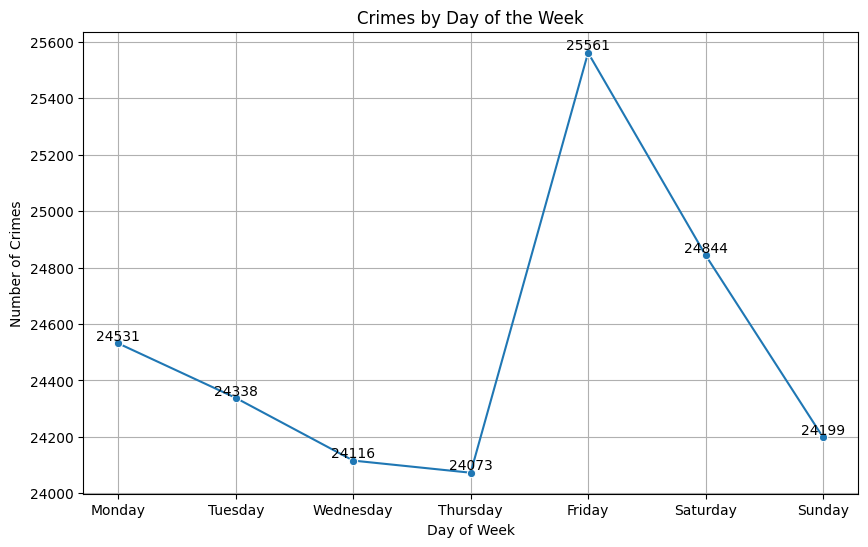

In [17]:
#REFINING BY DAYS
# Ensure 'DATE OF OCCURRENCE' is datetime type and handle NaT values
# Make a copy to avoid SettingWithCopyWarning if crime_data is a view
crime_data_processed = crime_data.copy()
crime_data_processed['DATE OF OCCURRENCE'] = pd.to_datetime(
    crime_data_processed['DATE OF OCCURRENCE'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)
crime_data_processed = crime_data_processed.dropna(subset=['DATE OF OCCURRENCE'])

crime_data_processed['DayOfWeek'] = crime_data_processed['DATE OF OCCURRENCE'].dt.day_name()

dow_counts = crime_data_processed['DayOfWeek'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(10,6))
sns.lineplot(x=dow_counts.index, y=dow_counts.values, marker='o')
plt.title("Crimes by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Crimes")
plt.grid(True)

for x, y in zip(dow_counts.index, dow_counts.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.show()

#MOST CRIMES HAPPEN ON FRIDAYS

QUESTION 5: Crime Variation by Month (Seasonality)

Insight:

- This line chart confirms the "seasonal effect" on crime, with a visible peak during the summer months (June–August) and a decline in the winter.

- Higher temperatures and longer daylight hours lead to more people in public spaces, which historically correlates with increased opportunities for both property and violent crimes in Chicago.

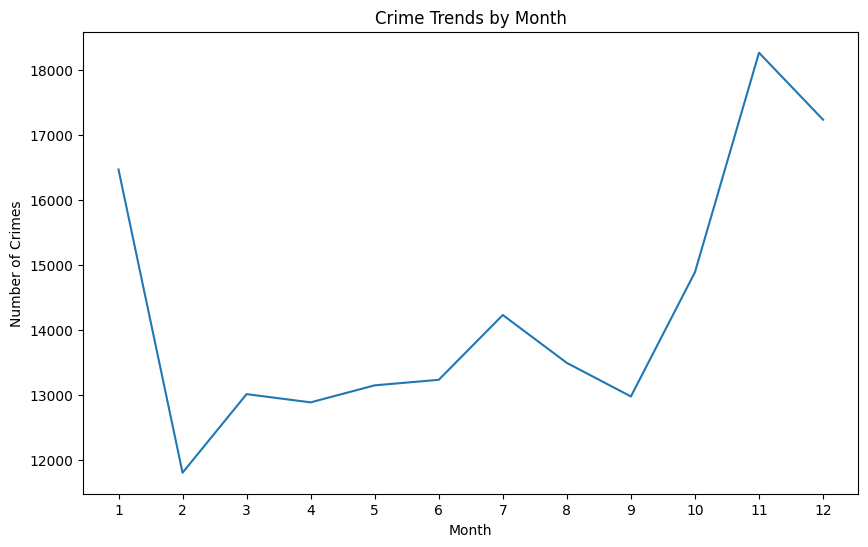

In [19]:

# Ensure 'DATE OF OCCURRENCE' is datetime type and handle NaT values
crime_data_processed = crime_data.copy()
crime_data_processed['DATE OF OCCURRENCE'] = pd.to_datetime(
    crime_data_processed['DATE OF OCCURRENCE'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)
crime_data_processed = crime_data_processed.dropna(subset=['DATE OF OCCURRENCE'])

crime_data_processed['Month'] = crime_data_processed['DATE OF OCCURRENCE'].dt.month

# Count crimes per month
monthly = crime_data_processed.groupby('Month').size().sort_index()

# Line plot
plt.figure(figsize=(10,6))
plt.plot(monthly.index, monthly.values)
plt.title("Crime Trends by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(range(1,13))
plt.show()

QUESTION 6: Geographic Hotspots (Top Wards/Districts)

Insight:

- Crime is not evenly distributed across Chicago; certain Wards or Districts show significantly higher counts than others.

- This visualization identifies specific geographic "hotspots" that require more intensive resource allocation and community intervention programs compared to the quieter residential sectors of the city.

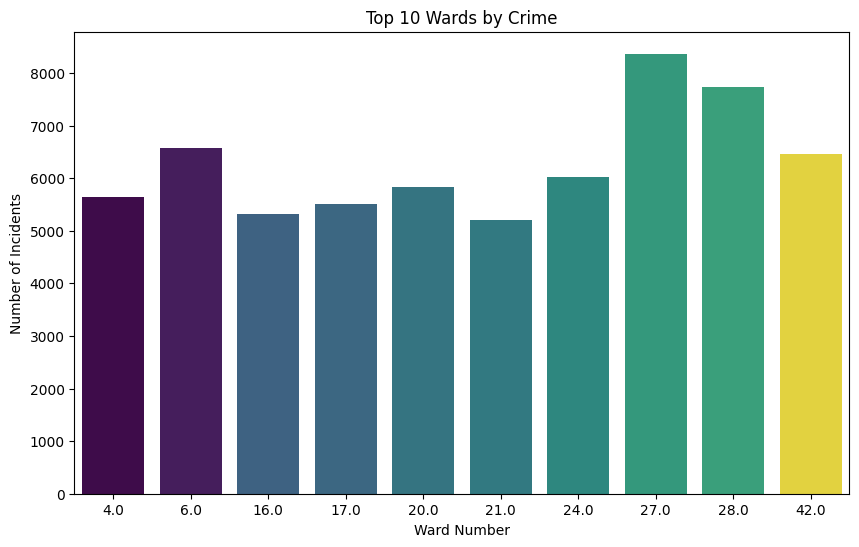

In [25]:
itop_areas = crime_data['WARD'].value_counts().head(10).sort_values(ascending=False)

plt.figure(figsize=(10,6))

# Vertical bar chart
sns.barplot(x=itop_areas.index, y=itop_areas.values, hue=itop_areas.index, palette="viridis", legend=False)

plt.title("Top 10 Wards by Crime")
plt.xlabel("Ward Number")
plt.ylabel("Number of Incidents")

plt.show()

#most crime happen in ward 27, followed by ward 28 and ward 6

QUESTION 7: Arrest vs. No Arrest (Volume Comparison)

Insight:

- This stacked bar chart highlights a concerning "justice gap" where the vast majority of reported crimes do not result in an immediate arrest.

-While some crimes like Narcotics have high arrest volumes, the massive "No Arrest" sections for Theft and Criminal Damage suggest that property crimes are much harder to clear than "on-view" offenses.

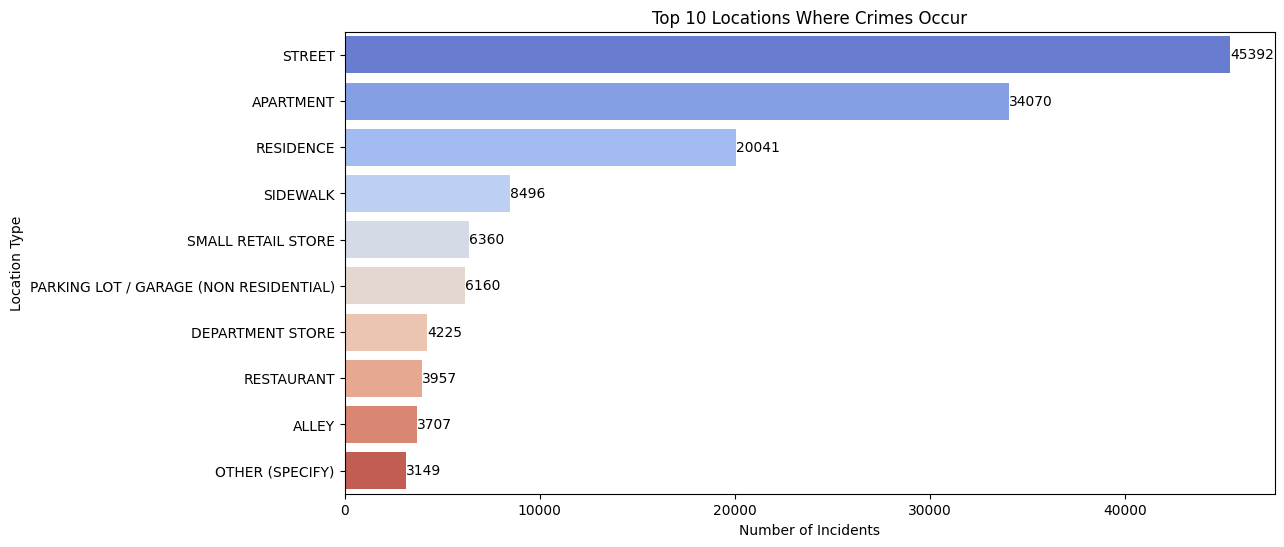

In [23]:
#ADDRESSING TOP LOCATIONS WHERE CRIMES OCCUR
top_locations = crime_data['LOCATION DESCRIPTION'].value_counts().head(10)

plt.figure(figsize=(12,6))
ax = sns.barplot(x=top_locations.values, y=top_locations.index, hue=top_locations.index, palette="coolwarm", legend=False)
plt.title("Top 10 Locations Where Crimes Occur")
plt.xlabel("Number of Incidents")
plt.ylabel("Location Type")

for i, value in enumerate(top_locations.values):
    ax.text(value + 5, i, str(value), va='center')

plt.show()

#MOST CRIMES HAPPEN IN THE STREET FOLLOWED BY APARTMENT, RESIDENCE AND SIDEWALK

QUESTION 8: Domestic vs. Non-Domestic Split

Insight:
- This chart provides critical social context, showing that Battery and Assault have a very high domestic component, occurring between family or household members.
- In contrast, Theft and Motor Vehicle Theft are almost exclusively non-domestic, allowing policymakers to distinguish between "community violence" and "domestic violence" when creating solutions.

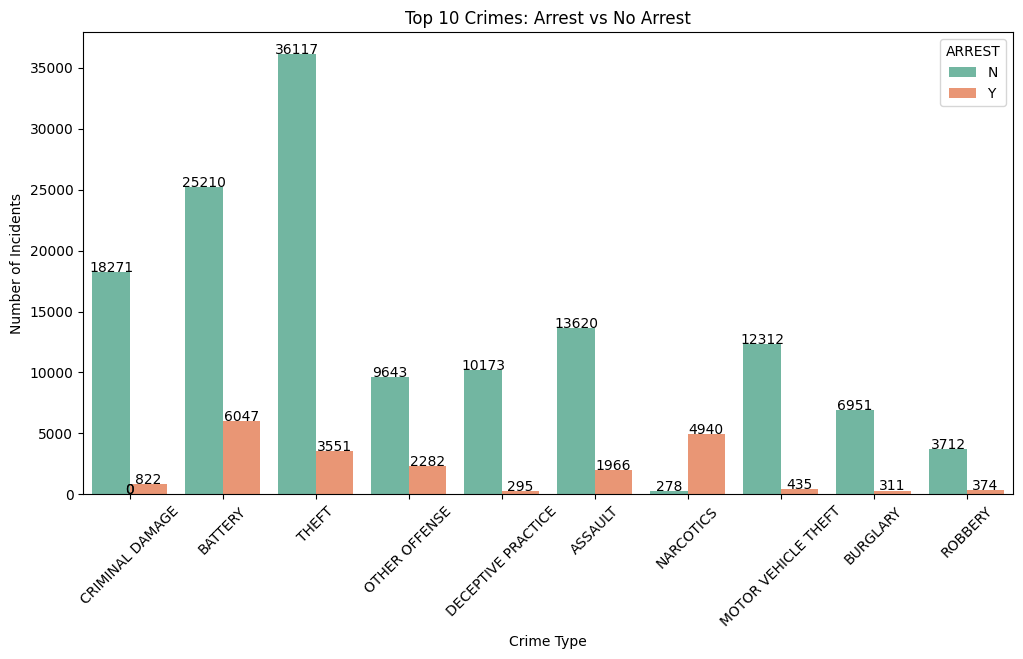

In [24]:
# Take top 10 crime types for clarity
top_crimes = crime_data['PRIMARY DESCRIPTION'].value_counts().head(10)
subset = crime_data[crime_data['PRIMARY DESCRIPTION'].isin(top_crimes.index)]

plt.figure(figsize=(12,6))
ax = sns.countplot(x='PRIMARY DESCRIPTION', hue='ARREST', data=subset, palette="Set2")
plt.title("Top 10 Crimes: Arrest vs No Arrest")
plt.xlabel("Crime Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)

# Add data labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 5, int(height), ha="center")

plt.show()

#crime with most arrrests are battery crime, followed by narcotics

QUESTION 9: Arrest Rate Percentage by Crime Type

Insight:
- This visualization shifts the focus from volume to efficiency, revealing that you are most likely to be arrested for Narcotics or Weapons Violations (often near 100%) and least likely for Theft.

- This tells us that police are highly effective at making arrests when the evidence is found on the person, but struggle with crimes that require follow-up investigation.

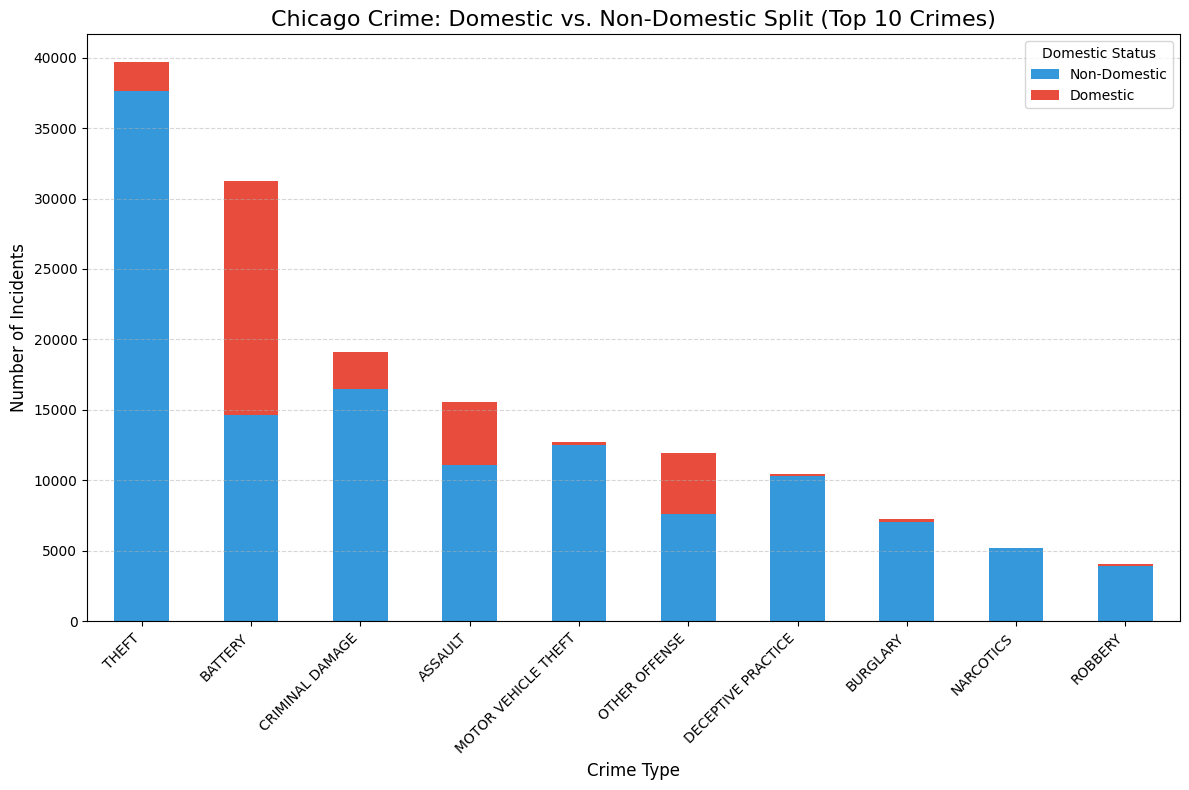

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your dataset
df = pd.read_csv('Crimes_-_One_year_prior_to_present.csv')

# 2. Clean column names (removing leading/trailing spaces)
df.columns = df.columns.str.strip()

# 3. Identify the Top 10 Crimes by volume
top_10_crimes = df['PRIMARY DESCRIPTION'].value_counts().nlargest(10).index
df_top10 = df[df['PRIMARY DESCRIPTION'].isin(top_10_crimes)]

# 4. Group data by Crime Type and Domestic status
# In this dataset, 'Y' = Yes (Domestic) and 'N' = No (Non-Domestic)
domestic_counts = df_top10.groupby(['PRIMARY DESCRIPTION', 'DOMESTIC']).size().unstack(fill_value=0)

# Sort the crimes by total volume for a better-looking chart
domestic_counts['Total'] = domestic_counts.sum(axis=1)
domestic_counts = domestic_counts.sort_values(by='Total', ascending=False).drop(columns='Total')

# Rename columns for clarity in the chart legend
domestic_counts = domestic_counts.rename(columns={'N': 'Non-Domestic', 'Y': 'Domestic'})

# 5. Create the Visualization
plt.figure(figsize=(12, 8))
domestic_counts.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=plt.gca())

plt.title('Chicago Crime: Domestic vs. Non-Domestic Split (Top 10 Crimes)', fontsize=16)
plt.xlabel('Crime Type', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Domestic Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('chicago_domestic_split.png')
plt.show()

# Optional: Save results to a CSV
domestic_counts.to_csv('domestic_split_analysis.csv')

QUESTION 10: Arrest Rate Percentage by Crime Type

Insight:

- This visualization reveals a dramatic disparity in law enforcement outcomes based on the nature of the crime. Narcotics and Weapons Violations show near-perfect arrest rates (close to 100%), which is typical for "proactive" policing where the arrest occurs at the moment the crime is discovered.

- Conversely, property crimes like Theft and Motor Vehicle Theft have the lowest arrest percentages, highlighting the extreme difficulty the CPD faces in solving "reactive" crimes where the offender has usually fled the scene before the police arrive.

/tmp/ipykernel_202/2229254444.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top10['arrest_numeric'] = df_top10['ARREST'].map({'Y': 1, 'N': 0})


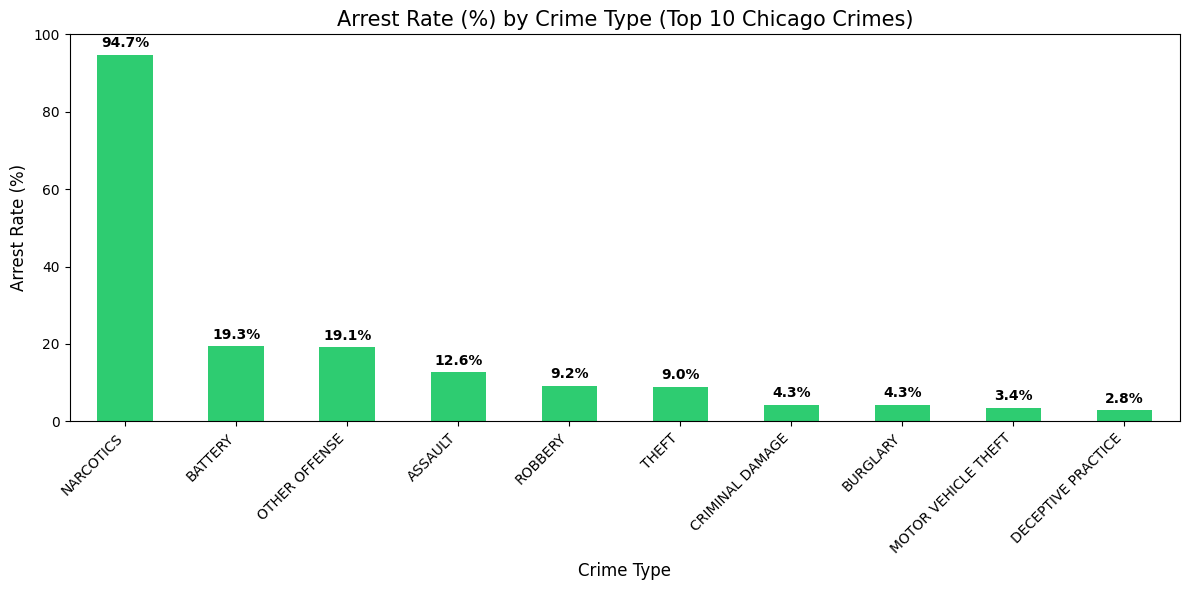

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('Crimes_-_One_year_prior_to_present.csv')
df.columns = df.columns.str.strip() # Clean column names

# 2. Filter for Top 10 Crimes to keep the chart readable
top_10_crimes = df['PRIMARY DESCRIPTION'].value_counts().nlargest(10).index
df_top10 = df[df['PRIMARY DESCRIPTION'].isin(top_10_crimes)]

# 3. Calculate the Arrest Rate (%)
# We group by Crime Type and calculate the mean of the ARREST column
# (assuming 'Y' is 1 and 'N' is 0)
df_top10['arrest_numeric'] = df_top10['ARREST'].map({'Y': 1, 'N': 0})
arrest_rate = df_top10.groupby('PRIMARY DESCRIPTION')['arrest_numeric'].mean() * 100
arrest_rate = arrest_rate.sort_values(ascending=False)

# 4. Visualization
plt.figure(figsize=(12, 6))
arrest_rate.plot(kind='bar', color='#2ecc71')

plt.title('Arrest Rate (%) by Crime Type (Top 10 Chicago Crimes)', fontsize=15)
plt.ylabel('Arrest Rate (%)', fontsize=12)
plt.xlabel('Crime Type', fontsize=12)
plt.ylim(0, 100) # Percentage scale
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of bars
for i, v in enumerate(arrest_rate):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('arrest_rate_percentage.png')
plt.show()

Summary of Main Lessons Learned
Through this exploratory analysis of the Chicago Crime dataset, several key patterns and insights have emerged regarding the safety landscape of the city over the past year:

Predictable Temporal Cycles: Criminal activity is not random; it follows a highly predictable temporal cycle. Crime volume peaks during the summer months, on weekend nights (Friday and Saturday), and during the late-evening hours (8 PM – Midnight). Conversely, the early morning hours (4 AM – 6 AM) and winter months represent the safest periods, suggesting that social activity and weather are major catalysts for crime.

The "Domestic" Nature of Violence: There is a clear divide in the nature of offenses. High-volume property crimes like Theft are almost entirely non-domestic and occur in public spaces. However, violent crimes such as Battery and Assault have a significant domestic component. This indicates that a large portion of the city's violence happens behind closed doors between familiar parties, requiring social intervention strategies that differ from traditional street patrols.

The Reactive Gap in Law Enforcement: A significant disparity exists in arrest efficiency. While Narcotics and Weapons Violations have near 100% arrest rates (likely due to proactive, "on-view" policing), property crimes like Motor Vehicle Theft and Burglary have extremely low arrest percentages. This "reactive gap" suggests that once an offender leaves the scene of a property crime, the likelihood of a successful apprehension drops dramatically.

Geographic and Environmental Concentration: Crime is heavily concentrated in specific "hotspots." Geographically, certain Wards and Districts carry a disproportionate amount of the city's crime load. Environmentally, the Street, Sidewalks, and Residential Buildings are the most frequent settings for incidents, highlighting the need for increased lighting and public surveillance in these specific areas.

Conclusion: To effectively reduce crime in Chicago, the data suggests a two-pronged approach: (1) increased public resource allocation during the "high-density" weekend and summer windows, and (2) a shift in focus toward domestic violence prevention and improved investigative technologies for property crimes where arrest rates are currently lagging.